In [1]:
import h5py
from scipy import signal
from scipy.signal import welch, csd
import matplotlib.pyplot as plt
from os import listdir
import numpy as np
from scipy import fft
import pickle
from datetime import datetime

In [2]:
folder = '/Users/21958742/DarkMatterCentre Dropbox/William Campbell/PhD/High Frequency GW/Data Analysis/MAGE3/run2/'

In [3]:
with open(folder + 'event_catalogue.pkl', 'rb') as f:
    event_catalogue = pickle.load(f)

In [4]:
len(event_catalogue)
event_catalogue2 = [event_catalogue[event] for event in event_catalogue if event_catalogue[event]['file N'] != 469]

In [41]:
SNRs1 = [(event_catalogue[event]['SNR'],event_catalogue[event]['noise']) for event in event_catalogue if event_catalogue[event]['input AI'] == 1]
SNRs0 =  [(event_catalogue[event]['SNR'],event_catalogue[event]['noise']) for event in event_catalogue if event_catalogue[event]['input AI'] == 0]
frequencies = [event_catalogue[event]['frequency'] for event in event_catalogue]

AI0_ch1_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 1) & (event_catalogue[event]['input AI']==0)]
AI0_ch2_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 2) & (event_catalogue[event]['input AI']==0)]
AI0_ch3_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 3) & (event_catalogue[event]['input AI']==0)]
AI0_ch4_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 4) & (event_catalogue[event]['input AI']==0)]
AI0_ch5_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 5) & (event_catalogue[event]['input AI']==0)]
AI0_ch6_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 6) & (event_catalogue[event]['input AI']==0)]
AI0_ch7_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 7) & (event_catalogue[event]['input AI']==0)]
AI0_ch8_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 8) & (event_catalogue[event]['input AI']==0)]
AI0_ch9_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 9) & (event_catalogue[event]['input AI']==0)]
AI0_ch10_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 10) & (event_catalogue[event]['input AI']==0)]
AI0_ch11_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 11) & (event_catalogue[event]['input AI']==0)]
AI0_ch12_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 12) & (event_catalogue[event]['input AI']==0)]
AI0_ch13_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 13) & (event_catalogue[event]['input AI']==0)]
AI0_ch14_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 14) & (event_catalogue[event]['input AI']==0)]
AI0_ch15_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 15) & (event_catalogue[event]['input AI']==0)]
AI0_ch16_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 16) & (event_catalogue[event]['input AI']==0)]

AI1_ch1_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 1) & (event_catalogue[event]['input AI']==1)]
AI1_ch2_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 2) & (event_catalogue[event]['input AI']==1)]
AI1_ch3_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 3) & (event_catalogue[event]['input AI']==1)]
AI1_ch4_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 4) & (event_catalogue[event]['input AI']==1)]
AI1_ch5_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 5) & (event_catalogue[event]['input AI']==1)]
AI1_ch6_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 6) & (event_catalogue[event]['input AI']==1)]
AI1_ch7_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 7) & (event_catalogue[event]['input AI']==1)]
AI1_ch8_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 8) & (event_catalogue[event]['input AI']==1)]
AI1_ch9_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 9) & (event_catalogue[event]['input AI']==1)]
AI1_ch10_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 10) & (event_catalogue[event]['input AI']==1)]
AI1_ch11_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 11) & (event_catalogue[event]['input AI']==1)]
AI1_ch12_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 12) & (event_catalogue[event]['input AI']==1)]
AI1_ch13_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 13) & (event_catalogue[event]['input AI']==1)]
AI1_ch14_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 14) & (event_catalogue[event]['input AI']==1)]
AI1_ch15_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 15) & (event_catalogue[event]['input AI']==1)]
AI1_ch16_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['noise']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 16) & (event_catalogue[event]['input AI']==1)]


In [42]:
ch1_norm_0, ch1_norm_1 = np.mean(np.array(AI0_ch1_events)[:,1])/4, np.mean(np.array(AI1_ch1_events)[:,1])/4
ch2_norm_0, ch2_norm_1 = np.mean(np.array(AI0_ch2_events)[:,1])/4, np.mean(np.array(AI1_ch2_events)[:,1])/4
ch3_norm_0, ch3_norm_1 = np.mean(np.array(AI0_ch3_events)[:,1])/4, np.mean(np.array(AI1_ch3_events)[:,1])/4
ch4_norm_0, ch4_norm_1 = np.mean(np.array(AI0_ch4_events)[:,1])/4, np.mean(np.array(AI1_ch4_events)[:,1])/4
ch5_norm_0, ch5_norm_1 = np.mean(np.array(AI0_ch5_events)[:,1])/4, np.mean(np.array(AI1_ch5_events)[:,1])/4
ch6_norm_0, ch6_norm_1 = np.mean(np.array(AI0_ch6_events)[:,1])/4, np.mean(np.array(AI1_ch6_events)[:,1])/4
ch7_norm_0, ch7_norm_1 = np.mean(np.array(AI0_ch7_events)[:,1])/4, np.mean(np.array(AI1_ch7_events)[:,1])/4
ch8_norm_0, ch8_norm_1 = np.mean(np.array(AI0_ch8_events)[:,1])/4, np.mean(np.array(AI1_ch8_events)[:,1])/4
ch9_norm_0, ch9_norm_1 = np.mean(np.array(AI0_ch9_events)[:,1])/4, np.mean(np.array(AI1_ch9_events)[:,1])/4
ch10_norm_0, ch10_norm_1 = np.mean(np.array(AI0_ch10_events)[:,1])/4, np.mean(np.array(AI1_ch10_events)[:,1])/4
ch11_norm_0, ch11_norm_1 = np.mean(np.array(AI0_ch11_events)[:,1])/4, np.mean(np.array(AI1_ch11_events)[:,1])/4
ch12_norm_0, ch12_norm_1 = np.mean(np.array(AI0_ch12_events)[:,1])/4, np.mean(np.array(AI1_ch12_events)[:,1])/4
ch13_norm_0, ch13_norm_1 = np.mean(np.array(AI0_ch13_events)[:,1])/4, np.mean(np.array(AI1_ch13_events)[:,1])/4
ch14_norm_0, ch14_norm_1 = np.mean(np.array(AI0_ch14_events)[:,1])/4, np.mean(np.array(AI1_ch14_events)[:,1])/4
ch15_norm_0, ch15_norm_1 = np.mean(np.array(AI0_ch15_events)[:,1])/4, np.mean(np.array(AI1_ch15_events)[:,1])/4
ch16_norm_0, ch16_norm_1 = np.mean(np.array(AI0_ch16_events)[:,1])/4, np.mean(np.array(AI1_ch16_events)[:,1])/4

In [43]:
normalised_events_0 = np.concatenate((
    (np.array(AI0_ch1_events)[:,0]*np.array(AI0_ch1_events)[:,1]/ch1_norm_0),
    (np.array(AI0_ch2_events)[:,0]*np.array(AI0_ch2_events)[:,1]/ch2_norm_0),
    (np.array(AI0_ch3_events)[:,0]*np.array(AI0_ch3_events)[:,1]/ch3_norm_0),
    (np.array(AI0_ch4_events)[:,0]*np.array(AI0_ch4_events)[:,1]/ch4_norm_0),
    (np.array(AI0_ch5_events)[:,0]*np.array(AI0_ch5_events)[:,1]/ch5_norm_0),
    (np.array(AI0_ch6_events)[:,0]*np.array(AI0_ch6_events)[:,1]/ch6_norm_0),
    (np.array(AI0_ch7_events)[:,0]*np.array(AI0_ch7_events)[:,1]/ch7_norm_0),
    (np.array(AI0_ch8_events)[:,0]*np.array(AI0_ch8_events)[:,1]/ch8_norm_0),
    (np.array(AI0_ch9_events)[:,0]*np.array(AI0_ch9_events)[:,1]/ch9_norm_0),
    (np.array(AI0_ch10_events)[:,0]*np.array(AI0_ch10_events)[:,1]/ch10_norm_0),
    (np.array(AI0_ch11_events)[:,0]*np.array(AI0_ch11_events)[:,1]/ch11_norm_0),
    (np.array(AI0_ch12_events)[:,0]*np.array(AI0_ch12_events)[:,1]/ch12_norm_0),
    (np.array(AI0_ch13_events)[:,0]*np.array(AI0_ch13_events)[:,1]/ch13_norm_0),
    (np.array(AI0_ch14_events)[:,0]*np.array(AI0_ch14_events)[:,1]/ch14_norm_0),
    (np.array(AI0_ch15_events)[:,0]*np.array(AI0_ch15_events)[:,1]/ch15_norm_0),
    (np.array(AI0_ch16_events)[:,0]*np.array(AI0_ch16_events)[:,1]/ch16_norm_0)
))

normalised_events_1 = np.concatenate((
    (np.array(AI1_ch1_events)[:,0]*np.array(AI1_ch1_events)[:,1]/ch1_norm_1),
    (np.array(AI1_ch2_events)[:,0]*np.array(AI1_ch2_events)[:,1]/ch2_norm_1),
    (np.array(AI1_ch3_events)[:,0]*np.array(AI1_ch3_events)[:,1]/ch3_norm_1),
    (np.array(AI1_ch4_events)[:,0]*np.array(AI1_ch4_events)[:,1]/ch4_norm_1),
    (np.array(AI1_ch5_events)[:,0]*np.array(AI1_ch5_events)[:,1]/ch5_norm_1),
    (np.array(AI1_ch6_events)[:,0]*np.array(AI1_ch6_events)[:,1]/ch6_norm_1),
    (np.array(AI1_ch7_events)[:,0]*np.array(AI1_ch7_events)[:,1]/ch7_norm_1),
    (np.array(AI1_ch8_events)[:,0]*np.array(AI1_ch8_events)[:,1]/ch8_norm_1),
    (np.array(AI1_ch9_events)[:,0]*np.array(AI1_ch9_events)[:,1]/ch9_norm_1),
    (np.array(AI1_ch10_events)[:,0]*np.array(AI1_ch10_events)[:,1]/ch10_norm_1),
    (np.array(AI1_ch11_events)[:,0]*np.array(AI1_ch11_events)[:,1]/ch11_norm_1),
    (np.array(AI1_ch12_events)[:,0]*np.array(AI1_ch12_events)[:,1]/ch12_norm_1),
    (np.array(AI1_ch13_events)[:,0]*np.array(AI1_ch13_events)[:,1]/ch13_norm_1),
    (np.array(AI1_ch14_events)[:,0]*np.array(AI1_ch14_events)[:,1]/ch14_norm_1),
    (np.array(AI1_ch15_events)[:,0]*np.array(AI1_ch15_events)[:,1]/ch15_norm_1),
    (np.array(AI1_ch16_events)[:,0]*np.array(AI1_ch16_events)[:,1]/ch16_norm_1)
))

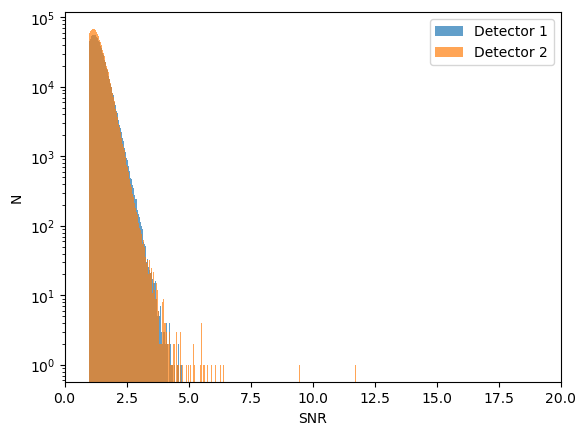

In [44]:
plt.hist(np.array(SNRs0)[:,0], bins=1000, alpha = 0.7, label = 'Detector 1')
plt.hist(np.array(SNRs1)[:,0], bins=1000, alpha = 0.7, label = 'Detector 2')
plt.yscale('log')
plt.xlabel('SNR')
plt.xlim(0,20)
plt.ylabel('N')
plt.legend(loc=0)
plt.show()

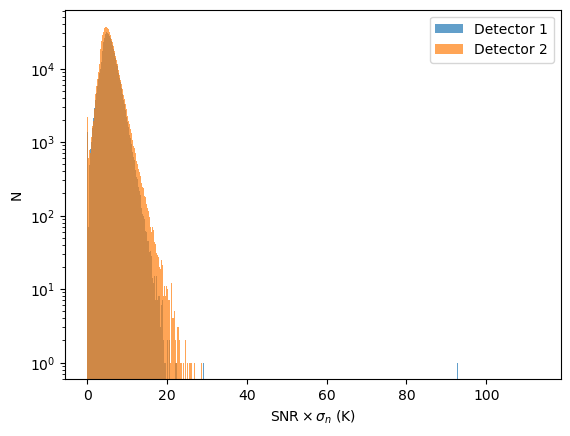

In [468]:
plt.hist(normalised_events_0, bins=1000, alpha = 0.7, label = 'Detector 1')
plt.hist(normalised_events_1, bins=1000, alpha = 0.7, label = 'Detector 2')
plt.yscale('log')
plt.xlabel(r'$\mathrm{SNR}\times\sigma_{n}$ (K)')
plt.ylabel('N')
plt.legend(loc=0)

In [469]:
normalised_cut_0 = [event for event in np.array(SNRs0)[:,0] if event>0]
normalised_cut_1 = [event for event in np.array(SNRs1)[:,0] if event>0]

In [470]:
Nbins = 250
ii=10
jj=25

Tn_height, Tn_edge = np.histogram(normalised_cut_0, bins = Nbins)
Tn_wk_height, Tn_wk_edge = np.histogram(normalised_cut_1, bins = Nbins)


Tfit_m, Tfit_b = np.polyfit(Tn_edge[ii:jj],np.log(Tn_height[ii:jj]+1),1)
Tfit_wk_m, Tfit_wk_b = np.polyfit(Tn_wk_edge[ii:jj],np.log(Tn_wk_height[ii:jj]+1),1)

tn_T = np.linspace(0.0,max(Tn_edge)*0.99,Nbins)

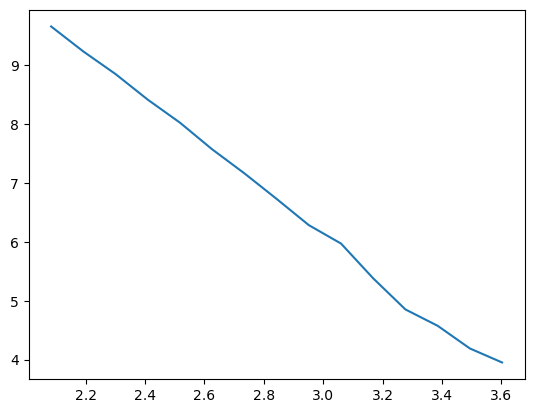

In [471]:
plt.plot(Tn_edge[ii:jj],np.log(Tn_height[ii:jj]+1))

In [472]:
excess_events = [excess_index for excess_index in range(len(Tn_wk_height)) if Tn_wk_height[excess_index] > 2*np.exp(Tfit_wk_m*Tn_wk_edge[excess_index]+Tfit_wk_b)]

excess_heights = [Tn_wk_height[i] for i in excess_events]
excess_edges = [Tn_wk_edge[i] for i in excess_events]

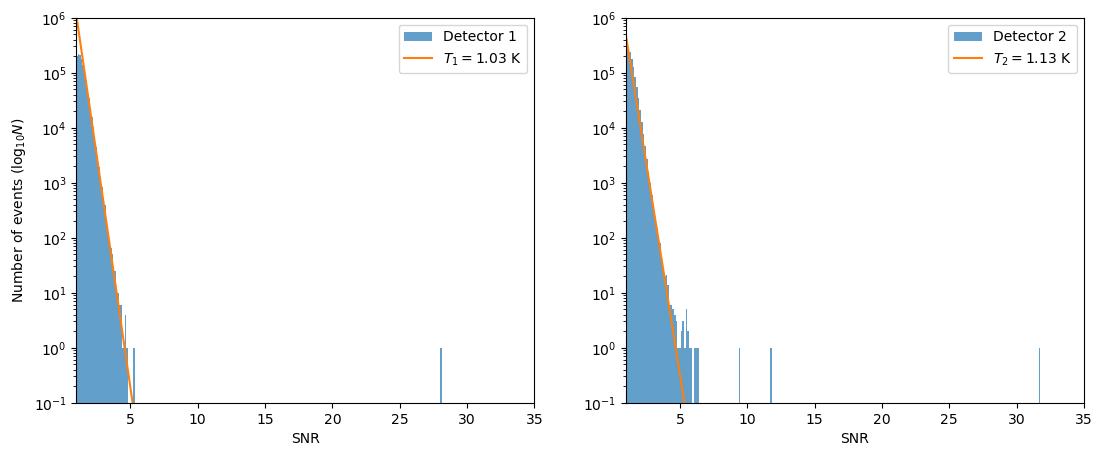

In [473]:
fig,ax = plt.subplots(1,2, figsize=(13,5))
ax[0].hist(normalised_cut_0,bins=Nbins, linewidth=0, alpha = 0.7, label='Detector 1')
ax[1].hist(normalised_cut_1,bins=Nbins,linewidth=0, alpha = 0.7, label = 'Detector 2')

ax[0].plot(tn_T,np.exp(Tfit_m*tn_T+Tfit_b), label = r'$T_1=$%1.2f' % (-1/Tfit_m*4) + ' K')
ax[1].plot(tn_T,np.exp(Tfit_wk_m*tn_T+Tfit_wk_b), label = r'$T_2=$%1.2f' % (-1/Tfit_wk_m*4) + ' K')
#ax.plot(excess_edges, excess_heights, linestyle = ' ', marker = 'x')
ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(0.1,1e6)
ax[0].set_xlim(1,35)
ax[1].set_ylim(0.1,1e6)
ax[1].set_xlim(1,35)
ax[0].set_xlabel(r'SNR')
ax[1].set_xlabel('SNR')
ax[0].set_ylabel(r'Number of events ($\mathrm{log}_{10}N$)')
pp = folder + 'hist.pdf'
plt.savefig(pp, format='pdf', dpi=600)

NameError: name 'normalised_cut_1' is not defined

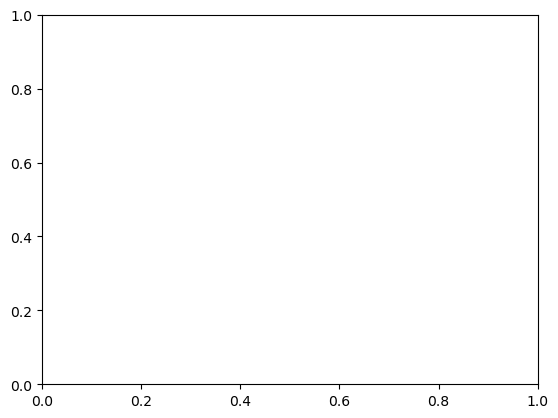

In [45]:
fig,ax = plt.subplots(1)
#ax.hist(normalised_cut_0,bins=Nbins, linewidth=0, alpha = 0.7)
ax.hist(normalised_cut_1,bins=Nbins,linewidth=0, alpha = 0.7)

#ax.plot(tn_T,np.exp(Tfit_m*tn_T+Tfit_b), label = r'$T_1=$%1.2f' % (-1/Tfit_m*4) + ' K')
ax.plot(tn_T,np.exp(Tfit_wk_m*tn_T+Tfit_wk_b), label = r'$T_2=$%1.2f' % (-1/Tfit_wk_m*4) + ' K')
#ax.plot(excess_edges, excess_heights, linestyle = ' ', marker = 'x')
ax.legend(loc=0)
ax.set_yscale('log')
ax.set_ylim(0.5,1e6)
ax.set_xlim(0,10)
ax.set_xlabel(r'SNR')
ax.set_ylabel(r'Number of events ($\mathrm{log}_{10}N$)')

In [33]:
large_events = [event for event in event_catalogue if 4<event_catalogue[event]['SNR']<5 and event_catalogue[event]['file N'] != 469]
xlarge_events = [event for event in event_catalogue if 5<event_catalogue[event]['SNR']<100 and event_catalogue[event]['file N'] != 469]

In [476]:
event_catalogue[large_events[8]]

{'time': datetime.datetime(2024, 5, 19, 12, 1, 53, 80431),
 'SNR': 4.057340686086931,
 'input AI': 0,
 'channel': 4,
 'frequency': 5505659.0,
 'noise': 3.296233508219074,
 'file N': 105,
 'index': 32730}

In [478]:
event_catalogue[xlarge_events[1]]

{'time': datetime.datetime(2024, 5, 17, 22, 56, 35, 591484),
 'SNR': 31.76057713150653,
 'input AI': 1,
 'channel': 3,
 'frequency': 5088263.0,
 'noise': 15.970563992319384,
 'file N': 56,
 'index': 172525}

In [5]:
times1 =  [event_catalogue[event]['time'].timestamp() for event in event_catalogue if (event_catalogue[event]['input AI'] == 1 and event_catalogue[event]['SNR'] > 1.0)]
times0 =  [event_catalogue[event]['time'].timestamp() for event in event_catalogue if (event_catalogue[event]['input AI'] == 0 and event_catalogue[event]['SNR'] > 1.0)]

In [6]:
coincident_0 = []
for time0 in times0:
    for time1 in times1:
        if np.abs(time0-time1) < 0.01:
            #print("Coincident Event at " + str(time0))
            coincident_0.append(time0)

KeyboardInterrupt: 

In [ ]:
coincident_1=[]
for time0 in times0:
    for time1 in times1:
        if np.abs(time0-time1) < 0.01:
            #print("Coincident Event at " + str(time1))
            coincident_1.append(time1)

In [ ]:
candidate_event = []

for ii in range(len(coincident_0)):
    co_event_nn = ii
    co_event = [(event, event_catalogue[event]) for event in event_catalogue if event_catalogue[event]['time'] == datetime.fromtimestamp(coincident_0[co_event_nn])], [(event, event_catalogue[event]) for event in event_catalogue if event_catalogue[event]['time'] == datetime.fromtimestamp(coincident_1[co_event_nn])]
    if (co_event[0][0][1]['channel'] == co_event[1][0][1]['channel']):
        candidate_event.append(co_event)
print(len(candidate_event))